**Import required libraries:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

**Load CSV file:**

In [2]:
df = pd.read_csv("../data/mobile_money_transactions.csv")

**Dataset Overview:**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


**Check just 5 rows of the dataset:**

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**Checking all null values in the dataset:**

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

### **The business questions this project answers:**

**a. Summarize typical transaction behavior:**

**i. Measure of central tendency and variation:**  Establish standard transaction sizes and measure volume volatility to flag extreme deviations.

In [6]:
amount = df['amount']

amount_mean = amount.mean()
amount_median = amount.median()
amount_mode = amount.mode()
amount_std = amount.std()

print(f"Mean of the amount: {amount_mean:.3f}")
print(f"Median of the amount: {amount_median:.3f}")
print(f"Mode of the amount: {amount_mode}")
print(f"Standard deviation of the amount: {amount_std}")

Mean of the amount: 179861.904
Median of the amount: 74871.940
Mode of the amount: 0    10000000.0
Name: amount, dtype: float64
Standard deviation of the amount: 603858.2314629357


Interpretation: Mean is more than double the median, which indicates that the distribution is right-skewed.
Standard Deviation of 603,858 is 3.5 times bigger than the Mean of 179,861, proving that transaction amounts vary wildly and are heavily mixed with massive, unusual transfers.

**ii. Measure of distribution Shape:** To identify if the platform is safe and stable.

In [7]:
skewness = amount.skew()
kurtosis = amount.kurt()
print(f"skewness: {skewness:.3f}")
print(f"Kurtosis: {kurtosis:.3f}")

skewness: 30.994
Kurtosis: 1797.957


Interpretation: Skewness (30.994): A perfectly normal and balanced dataset should have a Skewness near 0. Your score of 30.994 proves the data is extremely distorted; while normal users make very small daily payments, the platform is flooded with rare, massive money transfers.

Kurtosis (1797.957): A normal healthy dataset should have an Excess Kurtosis near 0 (or an absolute Kurtosis of 3). Your massive score of 1797.957 acts as a severe red flag, proving the system is under heavy attack from an extreme number of wild anomalies (outliers) that strongly signal active fraud networks.

**iii. Quartiles and outlier detection boundary:**  To calculate automated financial ceilings that separate normal customer behavior from highly suspicious activities.

In [8]:
Q1 = amount.quantile(0.25)
Q3 = amount.quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR", IQR)

Q1: 13389.57
Q3: 208721.4775
IQR 195331.9075


**Interpretation:**
IQR (195,331.91): Confirms that the middle 50% of your everyday users transact within a stable range of ~195K Taka.

Lower Bound (-279,608.29): Since transaction amounts cannot be negative in business, this lower limit has no real-world operational value.

Upper Bound (501,719.34): This sets a strict financial ceiling at roughly 501K Taka; any transfer above this limit is an anomaly that should automatically trigger a fraud review.

**iv. Visualizing Transaction Behavior and Anomalies:**

**Histogram:** To visualize the distribution of transaction amounts and identify patterns.

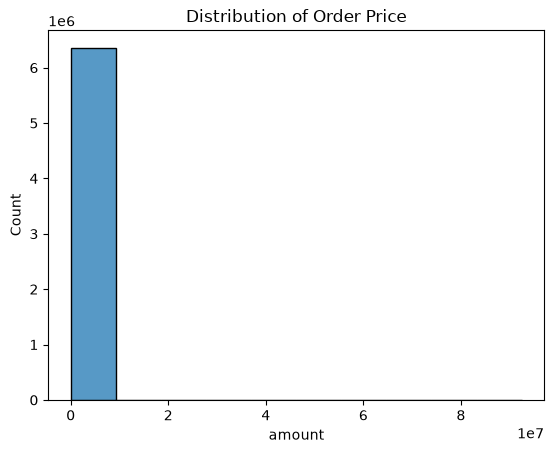

In [9]:
plt.Figure(figsize=(8, 5))
sns.histplot(amount, bins=10)
plt.title("Distribution of Order Price")
plt.show()

**Interpretation:** Most amount values are low, with a few extremely high values, resulting in a highly right-skewed distribution.

**Boxplot:** To visualize the spread of transaction amounts and identify outliers.

Text(0.5, 1.0, 'Boxplot - visually spot outliers beyond whiskers')

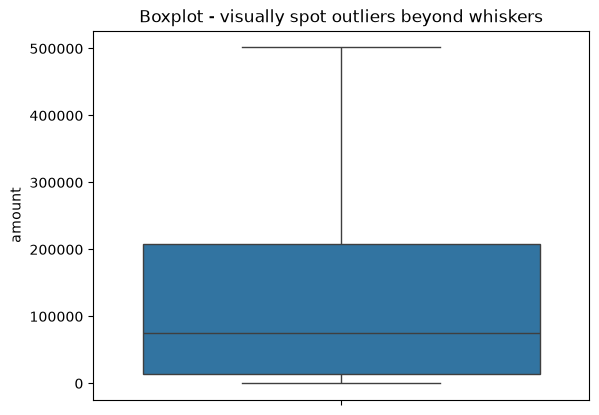

In [10]:
sns.boxplot(amount, showfliers=False)
plt.title("Boxplot - visually spot outliers beyond whiskers")

**Interpretation:** The data are widely spread, with a median of about 75,000 and several high-value outliers

### **Outlier Detection:**
 The descriptive statistics and visualizations above clearly identify a significant number of extreme outliers in the dataset. Now we quantify exactly which transactions are statistically abnormal - this is the literal first step of anyy real froud detection system.

**IQR:** Transaction data has many unusual high amounts that skew the average. IQR was chosen because it uses middle-range data, ensuring these extreme amounts do not ruin the outlier detection.

In [11]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(amount < lower_bound) | (amount > upper_bound)]

print(f"Lower_bound: {lower_bound} and Upper_bound: {upper_bound}")
print(f"IQR_outliers: {len(iqr_outliers)} ({len(iqr_outliers)/len(df)*100:.2f}%)")

print(f"Fraud rate amoung Z-score outliers: {iqr_outliers['isFraud'].mean()*100:.2f}%")
print(f"Fraud rate overall: {df['isFraud'].mean()*100:.2f}%")

Lower_bound: -279608.29125 and Upper_bound: 501719.33875
IQR_outliers: 338078 (5.31%)
Fraud rate amoung Z-score outliers: 1.14%
Fraud rate overall: 0.13%


**Interpretation:**  In the entire dataset, fraud is very rare—only 0.13% of all transactions are fraudulent. On the other hand, Inside the IQR outliers (transactions over $501,719), the fraud rate jumps to 1.14%.This means a high-amount outlier transaction is nearly 9 times more likely to be a fraud than a regular transaction. IQR successfully separated the high-risk transactions from the safe ones.

### **T-Test : Fraud vs. Non-Fraud Transaction Amount:**
We run this t-test to prove if fraud transactions use much bigger money amounts than normal ones, or if it is just a coincidence.

In [12]:
fraud_amount = df[df['isFraud'] == 1]['amount']
nonfraud_amount = df[df['isFraud'] == 0]['amount']

t_stat, p_val = stats.ttest_ind(fraud_amount, nonfraud_amount, equal_var=False)

print(f"Fraud avg amount: {fraud_amount.mean():2f} | Non-fraud avg amount: {nonfraud_amount.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.6f}")


Fraud avg amount: 1467967.299140 | Non-fraud avg amount: 178197.04
T-statistic: 48.615, p-value: 0.000000


**Interpretation:** Since the p-value is well below 0.05 (\(0.000 < 0.05\)) and the T-statistic is far greater than 2 (\(48.615 > 2\)), it mathematically proves that the massive gap between fraud and normal transaction amounts is 100% real and not a random coincidence.

**Bar Graph:** the average transaction amount comparison between fraud and non-fraud :

Text(0.5, 1.0, 'Avg Transaction Amount: Fraud vs Non-Fraud')

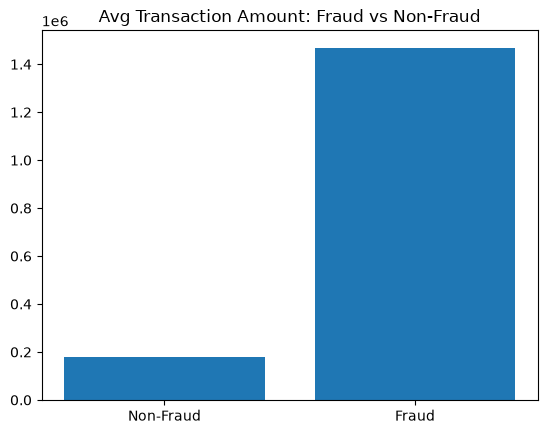

In [13]:
plt.bar(['Non-Fraud', 'Fraud'], [nonfraud_amount.mean(), fraud_amount.mean()])
plt.title('Avg Transaction Amount: Fraud vs Non-Fraud')

### **Confidence Interval:**
We run this t-test to prove if fraud transactions use much bigger money amounts than normal ones, or if it is just a coincidence.

In [14]:
ci_fraud = stats.t.interval(0.95, len(fraud_amount) - 1, loc=fraud_amount.mean(), scale=stats.sem(fraud_amount))
ci_nonfraud = stats.t.interval(0.95, len(nonfraud_amount) -1, loc=nonfraud_amount.mean(), scale=stats.sem(nonfraud_amount))

print(f"95% CI Fraud: {tuple(round(x,2) for x in ci_fraud)}")
print(f"95% CI Non-Fraud: {tuple(round(x,2) for x in ci_nonfraud)}")

95% CI Fraud: (np.float64(1415962.75), np.float64(1519971.85))
95% CI Non-Fraud: (np.float64(177733.46), np.float64(178660.63))


**Interpretation:** With 95% confidence, the true population mean for fraudulent transactions lies within a highly elevated range of $1.42M to $1.52M, whereas the mean for legitimate transactions remains constrained between $177K and $179K. The complete absence of overlap between these two intervals provides definitive statistical evidence that fraudulent activity systematically targets significantly higher financial volumes than normal transactions.

### **ANOVA — Transaction Amount Across Transaction Types**

Which transaction types handle the highest average amounts?

In [15]:
type_groups = [df[df['type']==t]['amount'] for t in df['type'].unique()]
f_stat, p_val = stats.f_oneway(*type_groups)

print(f"F-statistics: {f_stat:3f}, p-value: {p_val:.6f}")
print(df.groupby('type')['amount'].mean().sort_values(ascending=False))

F-statistics: 278715.542079, p-value: 0.000000
type
TRANSFER    910647.009645
CASH_OUT    176273.964346
CASH_IN     168920.242004
PAYMENT      13057.604660
DEBIT         5483.665314
Name: amount, dtype: float64


**Interpretation:** The p-value (\(p < 0.001\)) confirms that transaction differences across types are statistically real, while the massive F-statistic (\(278,715.54\)) proves this gap is exceptionally large. Specifically, TRANSFER dominates with an average of $910K—roughly 5 times larger than CASH_OUT and 70 times larger than PAYMENT—mathematically pinpointing it as the primary high-risk channel for large-scale fraud.

**Boxplot:** Transaction amount comparison across different transaction types

Text(0, 0.5, 'Amount (in Millions)')

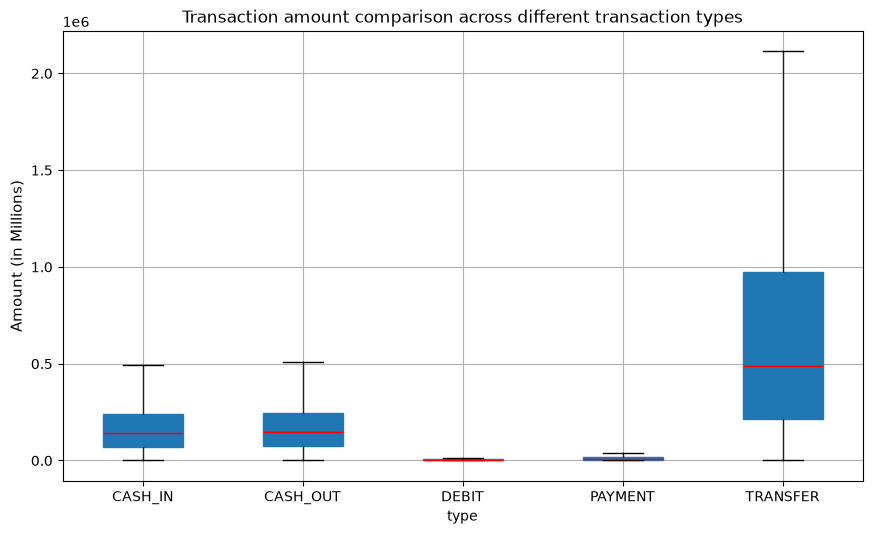

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

df.boxplot(column='amount', by='type', showfliers=False, ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#1f77b4', color='#1f77b4'), medianprops=dict(color='red', linewidth=1))

plt.suptitle('')
plt.title('Transaction amount comparison across different transaction types')
plt.ylabel('Amount (in Millions)', fontsize=11)

### **Correlation & Logistic Regression:**
To find out which money columns have the strongest direct connection to fraud.

In [17]:
corr_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']
corr_matrix = df[corr_cols].corr()
print(corr_matrix['isFraud'].sort_values(ascending=False))

df['balance_diff_org'] = df['oldbalanceOrg'] - df['newbalanceOrig']
x = df[['amount', 'oldbalanceOrg', 'balance_diff_org']]
x = sm.add_constant(x)
y =  df['isFraud']
logit_model = sm.Logit(y, x).fit(disp=0)
print(logit_model.summary())


isFraud           1.000000
amount            0.076688
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


c:\Users\nscom\OneDrive\Desktop\github_publications\MobileMoney_Fraud_projects\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:                isFraud   No. Observations:              6362620
Model:                          Logit   Df Residuals:                  6362616
Method:                           MLE   Df Model:                            3
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.5175
Time:                        22:17:58   Log-Likelihood:                -30320.
converged:                       True   LL-Null:                       -62844.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -6.8702      0.019   -367.694      0.000      -6.907      -6.834
amount           -1.535e-05   3.76e-07    -40.812      0.000   -1.61e-05   -1.46e-05
oldbalanceOrg    -2.828e-06 

c:\Users\nscom\OneDrive\Desktop\github_publications\MobileMoney_Fraud_projects\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


**Interpretation:**
* Amount (+0.076): Higher transaction amounts increase the risk of fraud. Fraudsters naturally prefer stealing larger sums of money.

* Old Balance (+0.010): Having more money in the account also increases fraud risk, but the current transaction amount is 8 times more critical than how much money was originally in the account.

* New Balance Orig (-0.008): The negative sign means as the victim's remaining balance drops closer to zero, the fraud risk shoots up. This mathematically catches the thief's behavior of completely draining the account.

* Destination Balances (~0.000): The receiver's account balances show nearly zero correlation. This proves that tracking the receiver's account is useless because fraudsters immediately cash out or move the money.

**Heatmap:** Correlation between transaction features and fraud:

Text(0.5, 1.0, 'Correlation between transaction features and fraud')

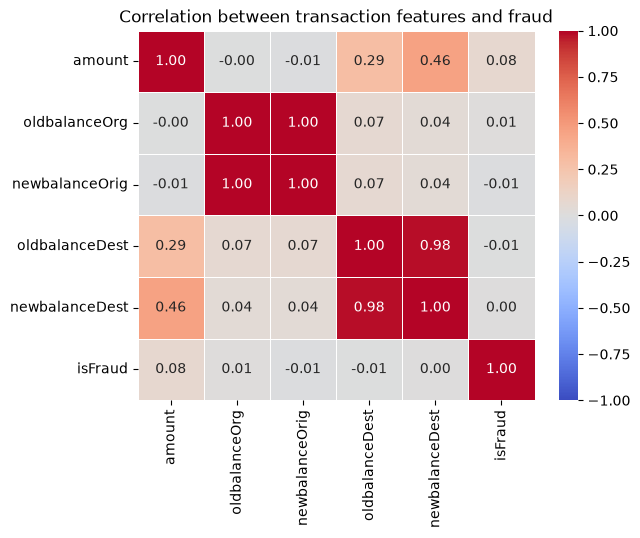

In [18]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation between transaction features and fraud')

sns.scatterplot(data=df, x='oldbalanceOrg', y='amount', hue='isFraud')
plt.title('Here representing the relationship between transaction amount and sender\'s balance, grouped by fraud status')

**Scatter:** Relationship between transaction amount and sender's balance, grouped by fraud status:

Text(0.5, 1.0, "Relationship between transaction amount and sender's balance, grouped by fraud status")

c:\Users\nscom\OneDrive\Desktop\github_publications\MobileMoney_Fraud_projects\.venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\nscom\OneDrive\Desktop\github_publications\MobileMoney_Fraud_projects\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


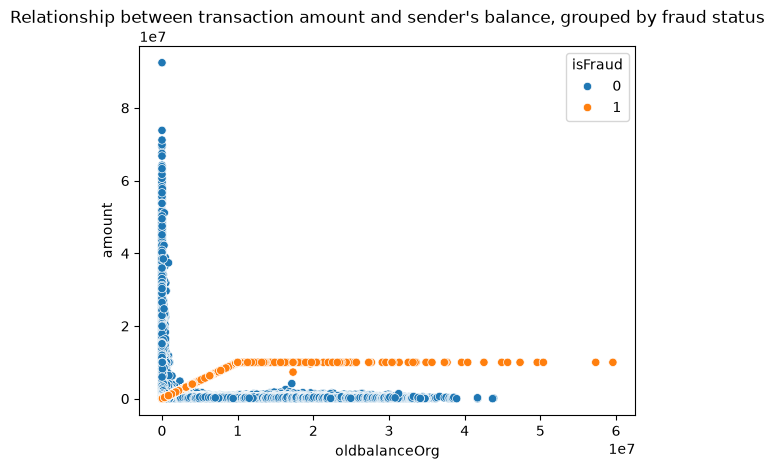

In [19]:
sns.scatterplot(data=df, x='oldbalanceOrg', y='amount', hue='isFraud')
plt.title('Relationship between transaction amount and sender\'s balance, grouped by fraud status')